Preprocessing function

In [ ]:
import re

def preprocess_complaint(text):

    if not isinstance(text, str):
        return ""

    # lowercase
    text = text.lower()

    # remove masked dates like xx/xx/xxxx
    text = re.sub(r'\b[x]{2}/[x]{2}/[x]{4}\b', ' ', text)

    # remove masked numbers like xxxx1234 or xxxx
    text = re.sub(r'\b[x]{2,}\d*\b', ' ', text)

    # normalize whitespace
    text = re.sub(r'\s+', ' ', text)

    return text.strip()

Mount Drive

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


Load data

In [ ]:
import pandas as pd

train_df = pd.read_parquet('/content/drive/MyDrive/aml/advanced_models/train_complaints.parquet')
test_df  = pd.read_parquet('/content/drive/MyDrive/aml/advanced_models/test_complaints.parquet')

In [ ]:
print(train_df.shape)
print(test_df.shape)

(812720, 4)
(203180, 4)


In [ ]:
train_df.head()

,Complaint ID,Consumer complaint narrative,Department,Priority
0,7251882,This is regarding the Texas B-On-Time Student ...,Student loan,high_priority
1,16800276,"On top of other discrepancies, XXXX XXXX accou...",Credit reporting,standard
2,2292018,There was fraudulent activity on my account wh...,Bank accounts,high_priority
3,7835057,I have consistently ensured my payments are ma...,Card services,standard
4,4313529,I tried to send them a letter last XX/XX/2020....,Mortgage,standard


Define features and targets

In [ ]:
X_train = train_df["Consumer complaint narrative"]
X_test  = test_df["Consumer complaint narrative"]

y_train_dept = train_df["Department"]
y_test_dept  = test_df["Department"]

y_train_priority = train_df["Priority"]
y_test_priority  = test_df["Priority"]

Preprocess text

In [ ]:
X_train_clean = [preprocess_complaint(x) for x in X_train]
X_test_clean  = [preprocess_complaint(x) for x in X_test]

Encode Labels

In [ ]:
from sklearn.preprocessing import LabelEncoder

le_priority = LabelEncoder()
y_train_priority_enc = le_priority.fit_transform(y_train_priority)
y_test_priority_enc  = le_priority.transform(y_test_priority)

Tokenization

In [ ]:
from transformers import AutoTokenizer

tokenizer = AutoTokenizer.from_pretrained("distilbert-base-uncased")

def tokenize(texts):
    return tokenizer(
        texts,
        padding=True,
        truncation=True,
        max_length=256
    )

train_encodings = tokenize(X_train_clean)
test_encodings  = tokenize(X_test_clean)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

Create Dataset

In [ ]:
import torch

class ComplaintDataset(torch.utils.data.Dataset):
    def __init__(self, encodings, labels):
        self.encodings = encodings
        self.labels = labels

    def __getitem__(self, idx):
        item = {k: torch.tensor(v[idx]) for k, v in self.encodings.items()}
        item["labels"] = torch.tensor(self.labels[idx])
        return item

    def __len__(self):
        return len(self.labels)

Build datasets - Priority

In [ ]:
train_dataset = ComplaintDataset(train_encodings, y_train_priority_enc)
test_dataset  = ComplaintDataset(test_encodings, y_test_priority_enc)

Load Model

In [ ]:
from transformers import AutoModelForSequenceClassification

model = AutoModelForSequenceClassification.from_pretrained(
    "distilbert-base-uncased",
    num_labels=len(le_priority.classes_)
)

model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_projector.bias    | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
pre_classifier.bias     | MISSING    | 
classifier.weight       | MISSING    | 
pre_classifier.weight   | MISSING    | 
classifier.bias         | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Training Setup

In [ ]:
from transformers import TrainingArguments

training_args = TrainingArguments(
    output_dir="/content/drive/MyDrive/aml/advanced_models/Priority_model_bert",
    learning_rate=2e-5,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,
    num_train_epochs=3,
    eval_strategy="epoch",  # <-- important fix
    save_strategy="epoch",
    load_best_model_at_end=True
)

Metrics

In [ ]:
from sklearn.metrics import accuracy_score, precision_recall_fscore_support
import numpy as np

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=1)

    precision_macro, recall_macro, f1_macro, _ = precision_recall_fscore_support(
        labels, preds, average="macro", zero_division=0
    )
    precision_weighted, recall_weighted, f1_weighted, _ = precision_recall_fscore_support(
        labels, preds, average="weighted", zero_division=0
    )
    acc = accuracy_score(labels, preds)

    return {
        "accuracy": acc,
        "precision_macro": precision_macro,
        "recall_macro": recall_macro,
        "f1_macro": f1_macro,
        "precision_weighted": precision_weighted,
        "recall_weighted": recall_weighted,
        "f1_weighted": f1_weighted,
    }

Train

In [ ]:
from transformers import Trainer

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=test_dataset,
    compute_metrics=compute_metrics
)

trainer.train()

# Final evaluation summary after training
final_metrics = trainer.evaluate()
print("\nFinal evaluation metrics:")
for k, v in final_metrics.items():
    print(f"{k}: {v}")

Epoch,Training Loss,Validation Loss,Accuracy,Precision Macro,Recall Macro,F1 Macro,Precision Weighted,Recall Weighted,F1 Weighted
1,0.297074,0.310286,0.870312,0.863086,0.866603,0.864693,0.871366,0.870312,0.870700
2,0.267373,0.289371,0.883527,0.877687,0.879448,0.878524,0.884151,0.883527,0.883795
3,0.216718,0.290282,0.888897,0.882660,0.885482,0.883982,0.889628,0.888897,0.889179


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['distilbert.embeddings.LayerNorm.weight', 'distilbert.embeddings.LayerNorm.bias'].
There were unexpected keys in the checkpoint model loaded: ['distilbert.embeddings.LayerNorm.beta', 'distilbert.embeddings.LayerNorm.gamma'].



Final evaluation metrics:
eval_loss: 0.28957363963127136
eval_accuracy: 0.8834334088000787
eval_precision_macro: 0.877540601362259
eval_recall_macro: 0.8794078447841415
eval_f1_macro: 0.8784271329259856
eval_precision_weighted: 0.8840685949260303
eval_recall_weighted: 0.8834334088000787
eval_f1_weighted: 0.8837035042207626
eval_runtime: 349.3184
eval_samples_per_second: 581.647
eval_steps_per_second: 36.354
epoch: 3.0


Confusion Matrix

Classification report:

               precision    recall  f1-score   support

     critical       0.86      0.88      0.87     51184
high_priority       0.83      0.84      0.83     67473
     standard       0.94      0.93      0.93     84523

     accuracy                           0.88    203180
    macro avg       0.88      0.88      0.88    203180
 weighted avg       0.88      0.88      0.88    203180



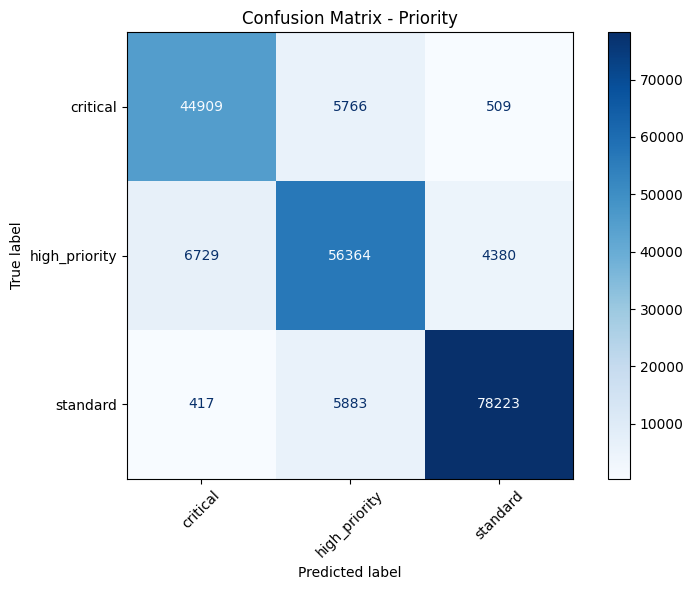

In [ ]:
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Get predictions on test set
pred_output = trainer.predict(test_dataset)
y_pred = np.argmax(pred_output.predictions, axis=1)
y_true = y_test_priority_enc

# Print per-class metrics
print("Classification report:\n")
print(classification_report(
    y_true,
    y_pred,
    target_names=le_priority.classes_,
    zero_division=0
))

# Plot confusion matrix
cm = confusion_matrix(y_true, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=le_priority.classes_)
fig, ax = plt.subplots(figsize=(8, 6))
disp.plot(ax=ax, cmap="Blues", values_format="d", xticks_rotation=45)
plt.title("Confusion Matrix - Priority")
plt.tight_layout()
plt.show()

In [7]:
import torch
from transformers import AutoModelForSequenceClassification

m = AutoModelForSequenceClassification.from_pretrained(
    "../models/priority-model-bert", local_files_only=True
)
state = m.state_dict()
for k in sorted(state.keys()):
    if "classifier" in k or "pre_classifier" in k:
        t = state[k]
        print(k, tuple(t.shape), "mean", float(t.mean()), "std", float(t.std()))

Loading weights:   0%|          | 0/104 [00:00<?, ?it/s]

classifier.bias (3,) mean -0.0004072748124599457 std 0.003244756953790784
classifier.weight (3, 768) mean -0.002650799695402384 std 0.022717010229825974
pre_classifier.bias (768,) mean 0.00025306621682830155 std 0.0031714686192572117
pre_classifier.weight (768, 768) mean -5.9839312598342076e-05 std 0.02048439346253872


In [8]:
import torch
from transformers import AutoModelForSequenceClassification

m = AutoModelForSequenceClassification.from_pretrained(
    "../models/priority-model-bert", local_files_only=True
)
b = m.classifier.bias.data
W = m.classifier.weight.data
print("bias per class:", b.tolist())
print("weight row L2 norms:", W.norm(dim=1).tolist())

Loading weights:   0%|          | 0/104 [00:00<?, ?it/s]

bias per class: [-0.0024137981235980988, 0.003336214227601886, -0.002144240541383624]
weight row L2 norms: [0.6420574188232422, 0.5536739826202393, 0.6970575451850891]
